In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector

# Helper to show probabilities clearly
def show_probs(state, title):
    display(plot_histogram(state.probabilities_dict(), title=title, figsize=(8, 4)))

Statevector after H: [0.70710678+0.j 0.70710678+0.j]


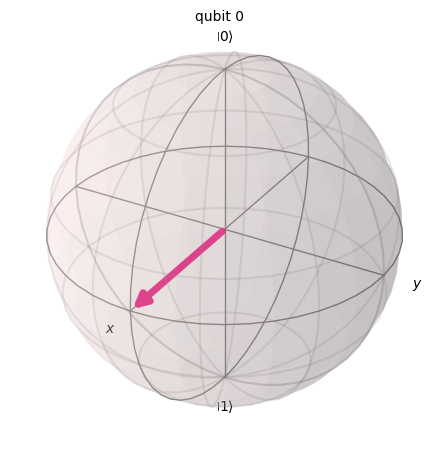

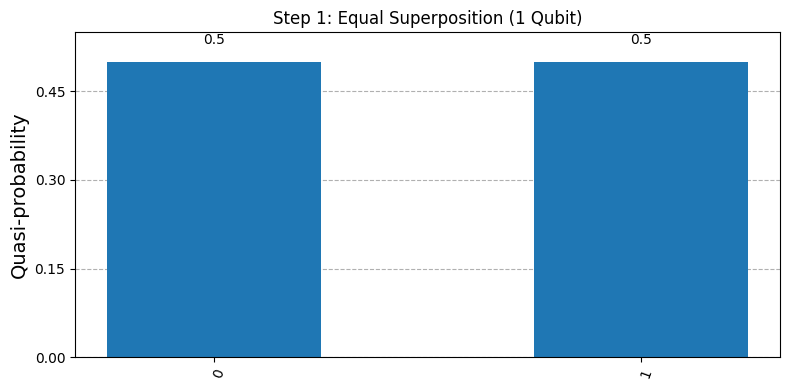

In [2]:
qc_1 = QuantumCircuit(1)
qc_1.h(0)

state = Statevector.from_instruction(qc_1)
print("Statevector after H:", state.data)
display(plot_bloch_multivector(state))
show_probs(state, "Step 1: Equal Superposition (1 Qubit)")

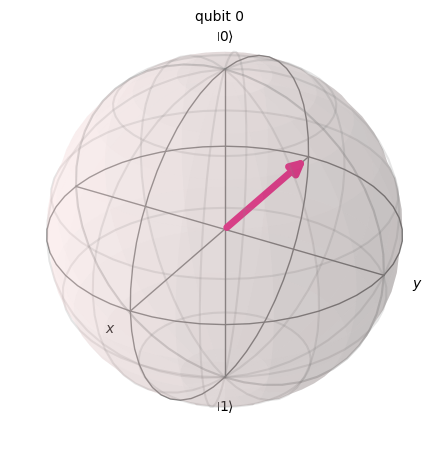

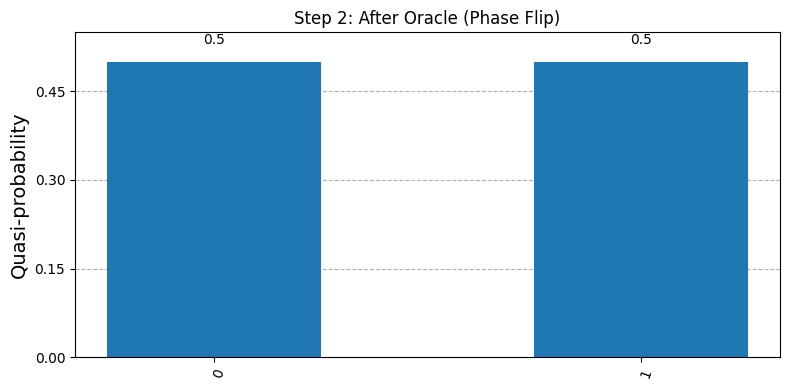

In [3]:
qc_1.z(0) # The Oracle for state '1'
state = Statevector.from_instruction(qc_1)
display(plot_bloch_multivector(state))
show_probs(state, "Step 2: After Oracle (Phase Flip)")

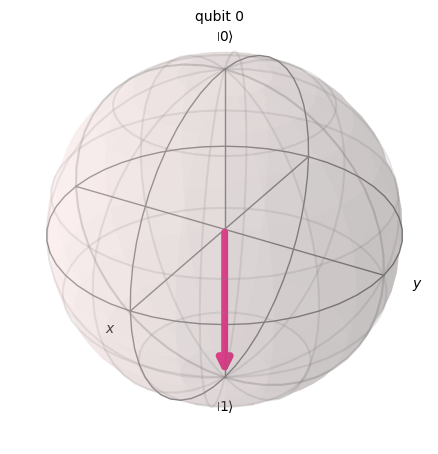

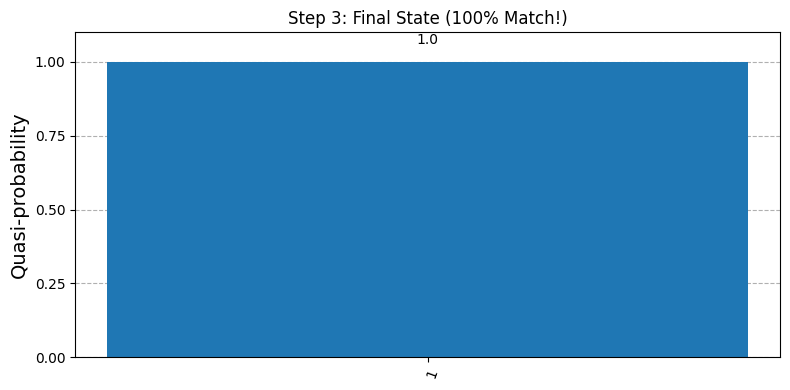

In [4]:
qc_1.h(0)
state = Statevector.from_instruction(qc_1)
display(plot_bloch_multivector(state))
show_probs(state, "Step 3: Final State (100% Match!)")

In [5]:
def get_oracle(target_str):
    """Flips the phase of the target bitstring."""
    n = len(target_str)
    qc = QuantumCircuit(n)
    # This logic marks the specific state by flipping its sign
    for i, bit in enumerate(reversed(target_str)):
        if bit == '0': qc.x(i)
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1) # Multi-controlled X
    qc.h(n-1)
    for i, bit in enumerate(reversed(target_str)):
        if bit == '0': qc.x(i)
    return qc.to_gate(label=" Oracle (Mark 0101) ")

def get_diffuser(n):
    """Amplifies the marked state."""
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc.to_gate(label=" Diffuser (Amplify) ")

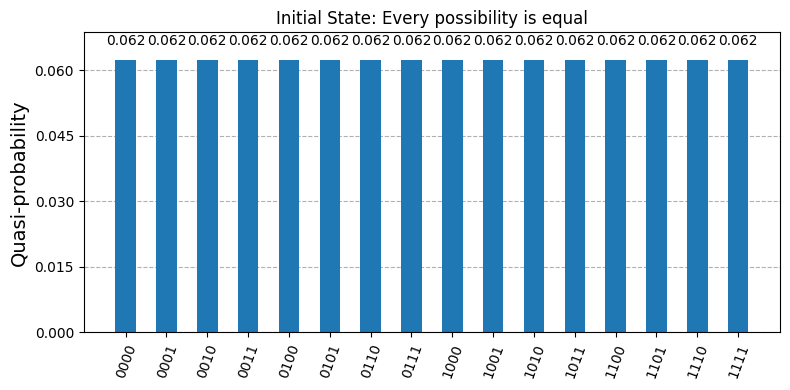

In [58]:
target = "0101"
n = 4
main_qc = QuantumCircuit(n)

# Step 1: Initialize Superposition
main_qc.h(range(n))
state = Statevector.from_instruction(main_qc)
show_probs(state, "Initial State: Every possibility is equal")

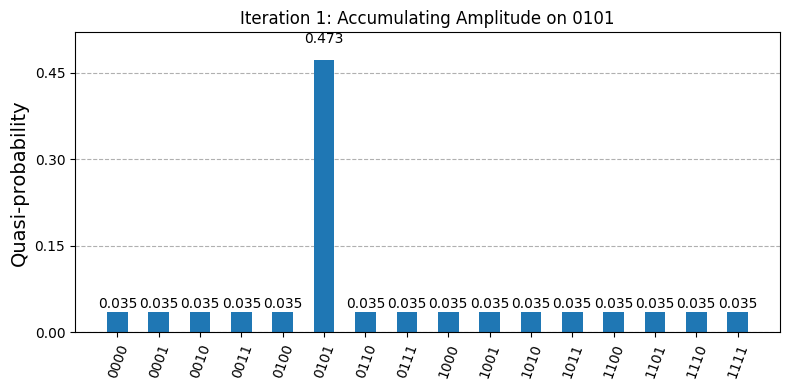

In [59]:
main_qc.append(get_oracle(target), range(n))
main_qc.append(get_diffuser(n), range(n))

state = Statevector.from_instruction(main_qc)
show_probs(state, f"Iteration {1}: Accumulating Amplitude on {target}")

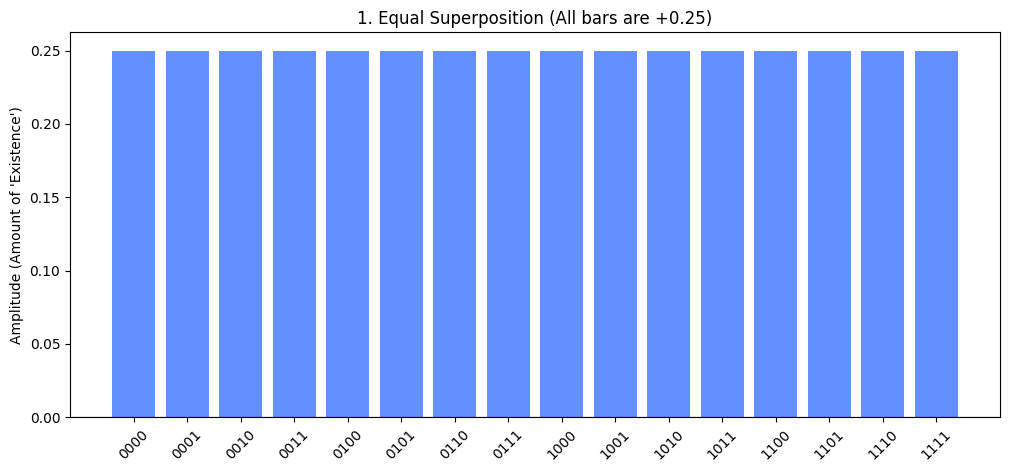

In [64]:
def plot_amplitudes(state, title="Statevector Amplitudes"):
    """Plots the real part of the amplitudes to show the sign flip."""
    amplitudes = state.data.real # Grover usually stays in the real plane
    labels = [format(i, '04b') for i in range(16)]
    
    plt.figure(figsize=(12, 5))
    colors = ['#648FFF' if a >= 0 else '#DC267C' for a in amplitudes]
    plt.bar(labels, amplitudes, color=colors)
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(title)
    plt.ylabel("Amplitude (Amount of 'Existence')")
    plt.show()

# --- DEMONSTRATION ---
n = 4
target = "0101"
qc_demo = QuantumCircuit(n)

# 1. Start with Equal Superposition
qc_demo.h(range(n))
state_initial = Statevector.from_instruction(qc_demo)
plot_amplitudes(state_initial, "1. Equal Superposition (All bars are +0.25)")

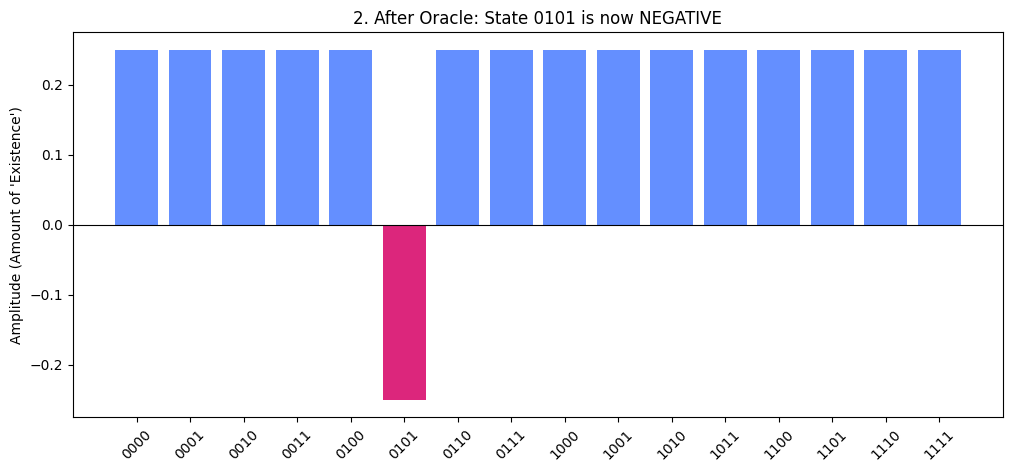

In [65]:
# 2. Apply the Oracle
qc_demo.append(get_oracle(target), range(n))
state_marked = Statevector.from_instruction(qc_demo)
plot_amplitudes(state_marked, f"2. After Oracle: State {target} is now NEGATIVE")

In [80]:
# Reset and run iterations
qc_search = QuantumCircuit(n)
qc_search.h(range(n))

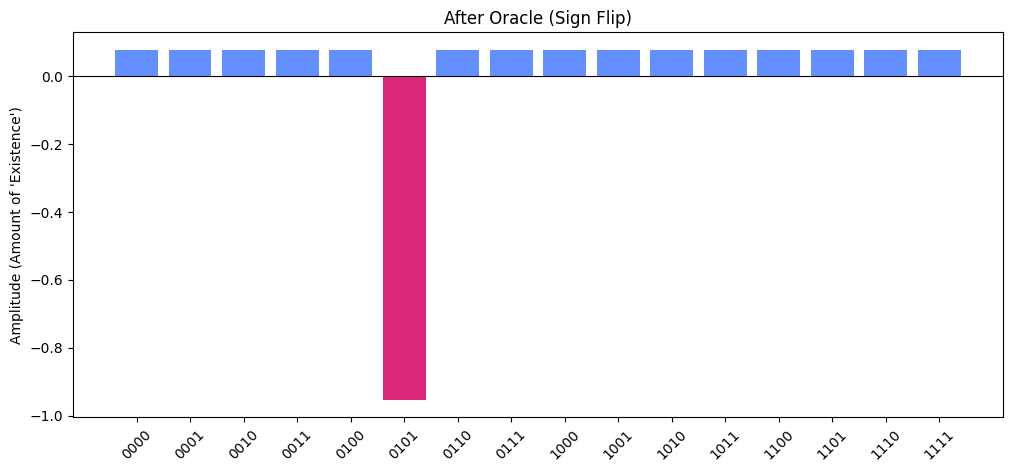

In [85]:
# Mark
qc_search.append(get_oracle(target), range(n))
state_after_oracle = Statevector.from_instruction(qc_search)
plot_amplitudes(state_after_oracle, f"After Oracle (Sign Flip)")

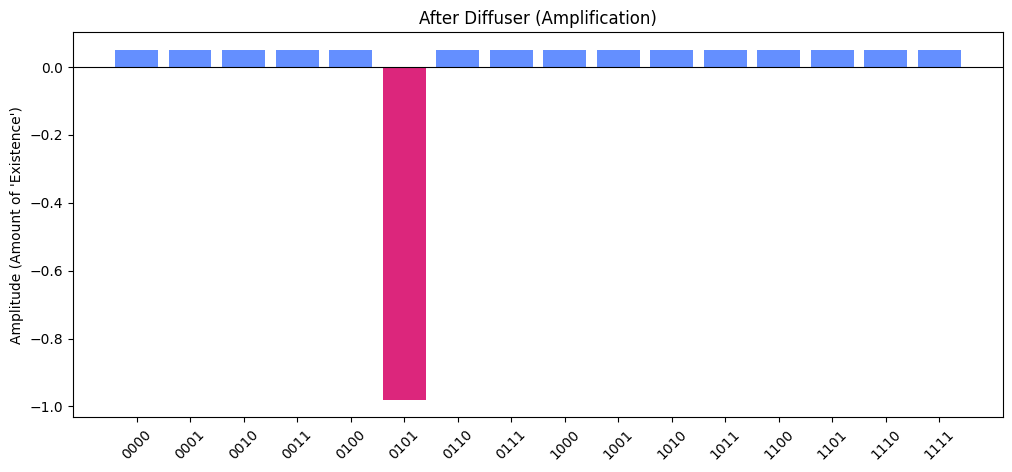

In [86]:
# Amplify
qc_search.append(get_diffuser(n), range(n))
state_after_diffuser = Statevector.from_instruction(qc_search)
plot_amplitudes(state_after_diffuser, f"After Diffuser (Amplification)")

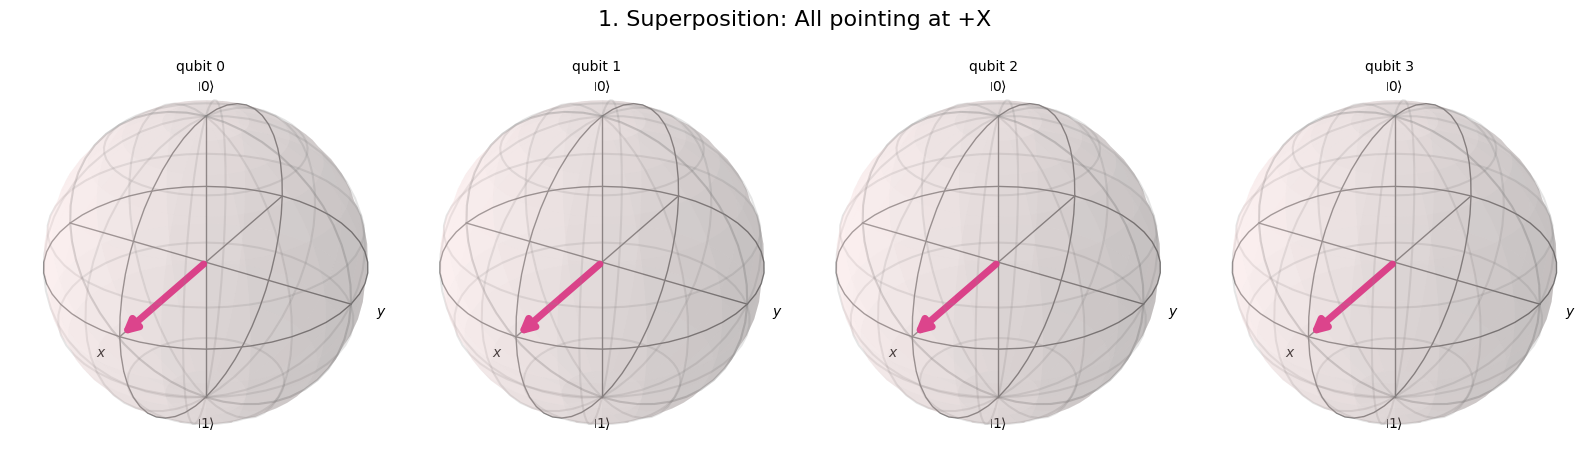

In [100]:
from qiskit.visualization import plot_bloch_multivector

# Setup 4 qubits for target 0101
n = 4
target = "0101"
qc_bloch = QuantumCircuit(n)

# 1. Start: Equal Superposition
qc_bloch.h(range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="1. Superposition: All pointing at +X"))

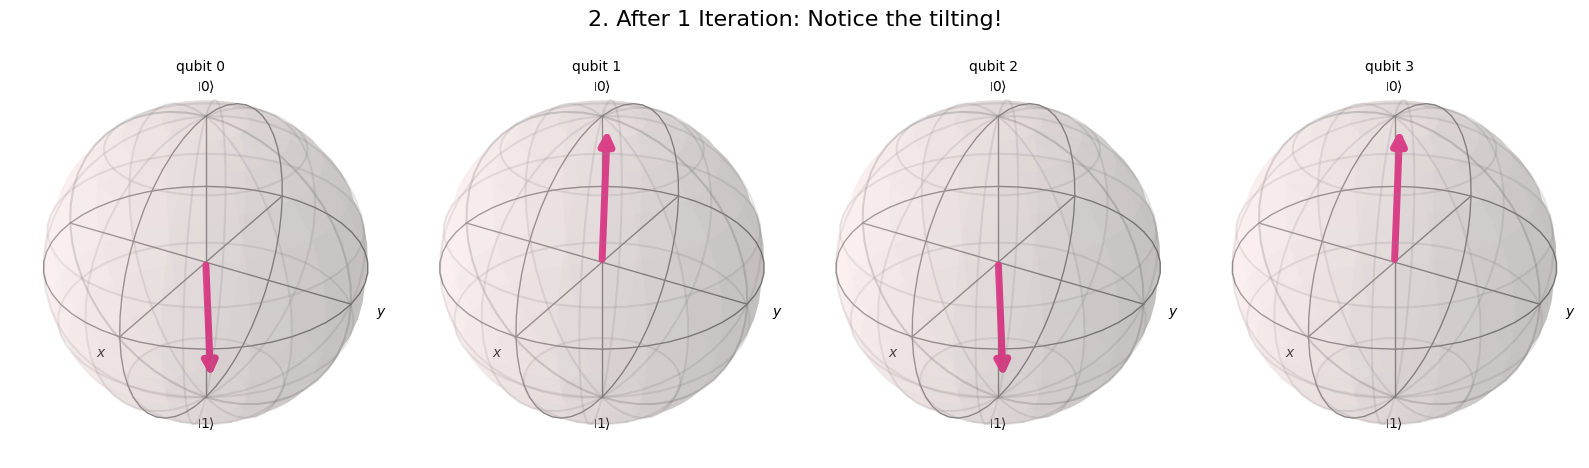

In [105]:
# 2. After 1 Iteration (Oracle + Diffuser)
qc_bloch.append(get_oracle(target), range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="2. After 1 Iteration: Notice the tilting!"))

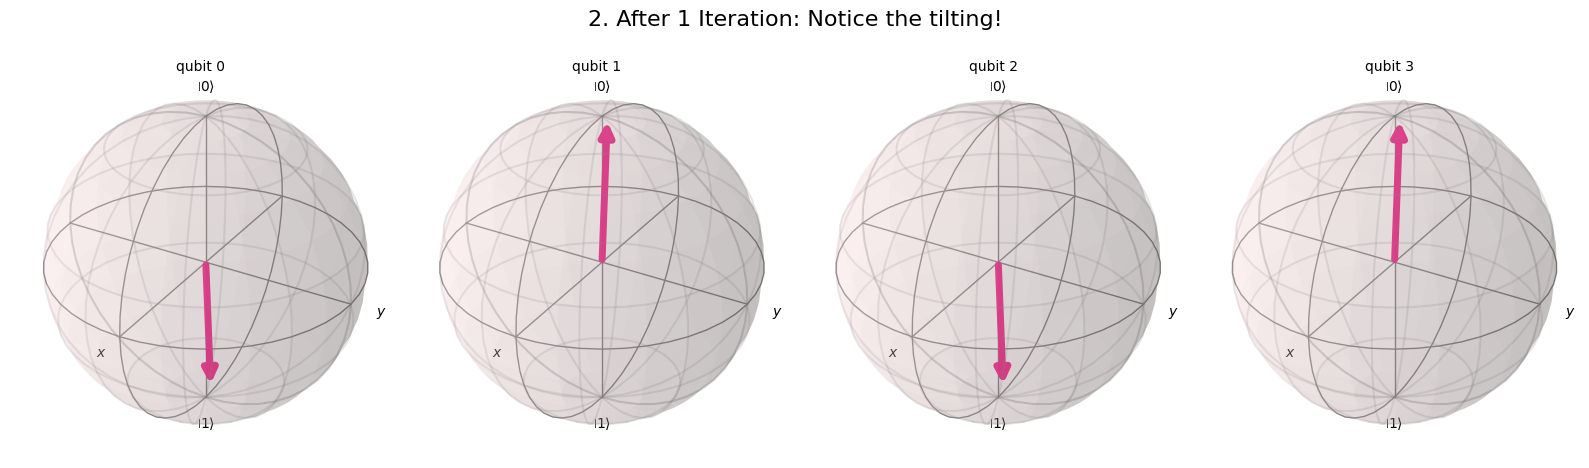

In [106]:
qc_bloch.append(get_diffuser(n), range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="2. After 1 Iteration: Notice the tilting!"))